In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = '/content/drive/MyDrive/Underwater_Project'
os.chdir(project_path)

print("Current Directory:", os.getcwd())
!ls

Current Directory: /content/drive/.shortcut-targets-by-id/1LfrJe7A76_b9zEB1Akxx8s3t6aVI0J07/Underwater_Project
best1.pt		Final_Predictions	      yolo11m.pt
datasets		Mehul_DL		      yolo26n.pt
FasterRCNN_Predictions	pytorch-CycleGAN-and-pix2pix  YOLO_Ablation_Studies
FasterRCNN_Results	Test_Images		      yolo_dataset
Final_Dataset		Weights			      YOLO_Results


YOLO

In [ ]:
import os
import shutil
import yaml

print("Installing Ultralytics...")
%pip install ultralytics
from ultralytics import YOLO

Installing Ultralytics...


In [ ]:
import os
import yaml

os.makedirs('/content/yolo_dataset', exist_ok=True)

print("Starting a high-stability copy... this will take 3-5 minutes.")
!cp -r /content/drive/MyDrive/Underwater_Project/yolo_dataset/* /content/yolo_dataset/

yaml_content = {
    'train': '/content/yolo_dataset/images/train',
    'val': '/content/yolo_dataset/images/val',
    'nc': 4,
    'names': ['holothurian', 'echinus', 'scallop', 'starfish']
}

with open('/content/yolo_dataset/data.yaml', 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print("\n Dataset copied and data.yaml created!")

Starting a high-stability copy... this will take 3-5 minutes.

 Dataset copied and data.yaml created!


In [ ]:
print(f"Images in train: {len(os.listdir('/content/yolo_dataset/images/train'))}")
print(f"Labels in train: {len(os.listdir('/content/yolo_dataset/labels/train'))}")

Images in train: 4005
Labels in train: 4000


In [ ]:
!yolo task=detect mode=train \
model=yolo11m.pt \
data=/content/yolo_dataset/data.yaml \
epochs=80 \
patience=25 \
batch=16 \
imgsz=640 \
project=/content/drive/MyDrive/Underwater_Project/Mehul_DL \
name=urpc_medium_final_run

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=urpc_medium_final_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

 Running predictions on real, unseen underwater images...

image 1/9 /content/drive/MyDrive/Underwater_Project/Test_Images/000434.jpg: 192x320 2 echinuss, 48.3ms
image 2/9 /content/drive/MyDrive/Underwater_Project/Test_Images/000635.jpg: 192x320 9 echinuss, 39.5ms
image 3/9 /content/drive/MyDrive/Underwater_Project/Test_Images/000776.jpg: 192x320 4 echinuss, 38.4ms
image 4/9 /content/drive/MyDrive/Underwater_Project/Test_Images/000784.jpg: 192x320 5 echinuss, 1 starfish, 39.9ms
image 5/9 /content/drive/MyDrive/Underwater_Project/Test_Images/001013.jpg: 192x320 3 scallops, 54.2ms
image 6/9 /content/drive/MyDrive/Underwater_Project/Test_Images/001183.jpg: 192x320 2 echinuss, 1 starfish, 41.1ms
image 7/9 /content/drive/MyDrive/Underwater_Project/Test_Images/001192.jpg: 192x320 1 starfish, 43.5ms
image 8/9 /content/drive/MyDrive/Underwater_Project/Test_Images/001294.jpg: 192x320 6 echinuss, 7 scallops, 45.2ms
image 9/9 /content/drive/MyDrive/Underwater_Project/Test_Images/005536.jpg: 192x3

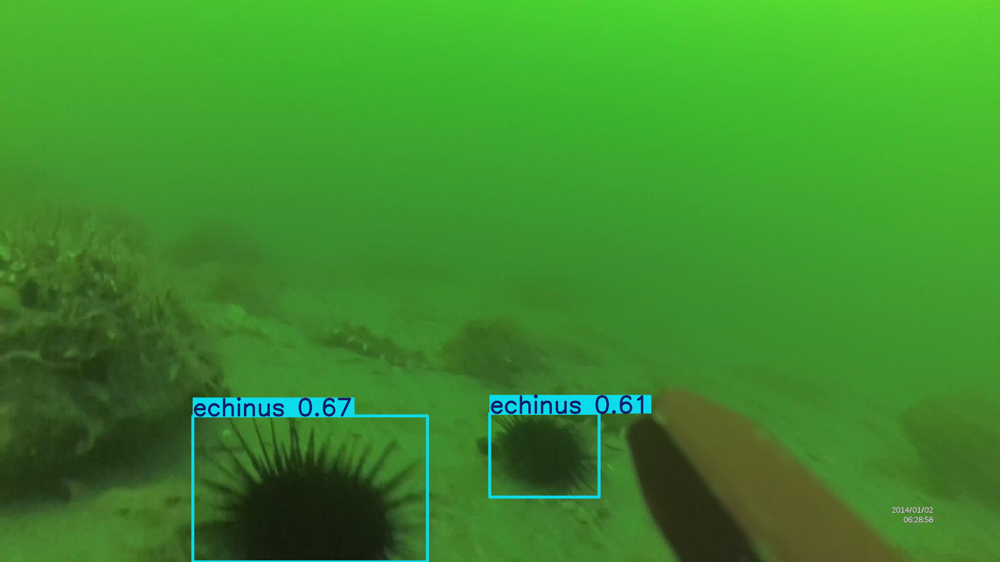

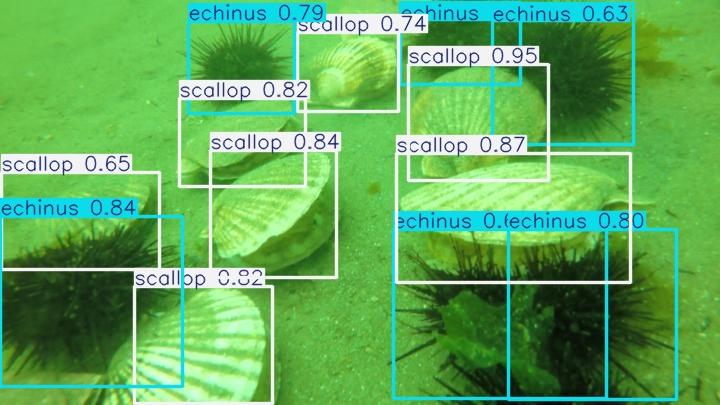

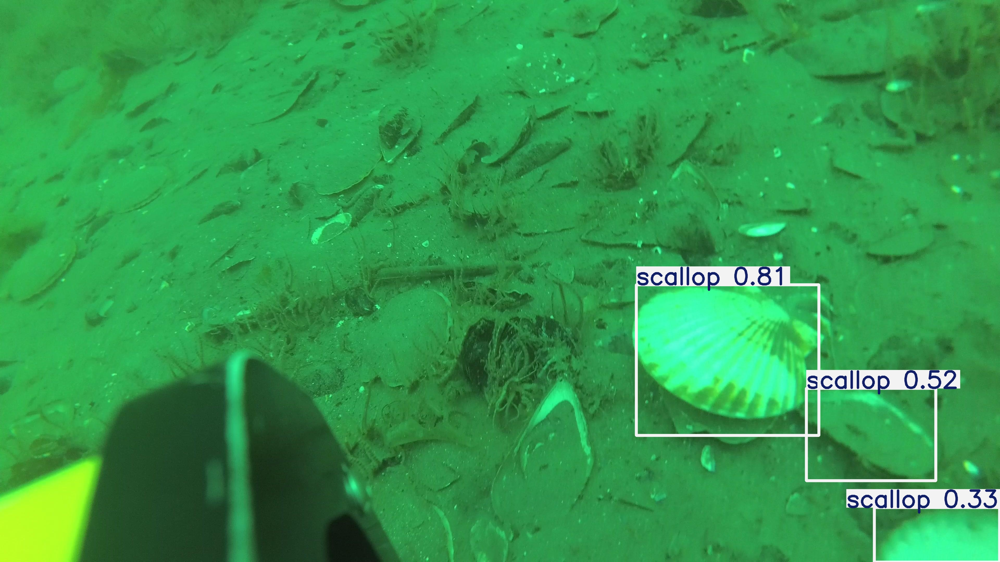

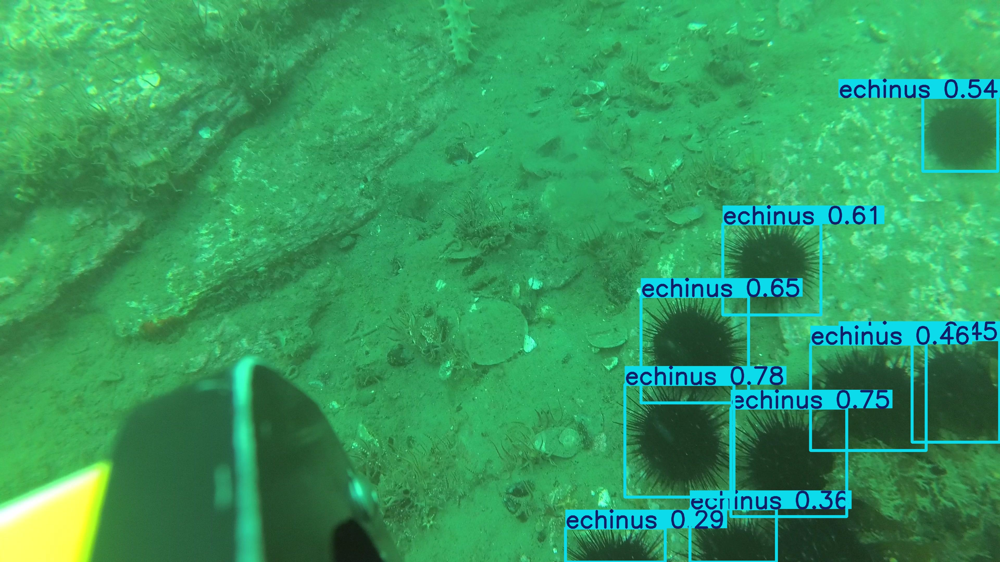

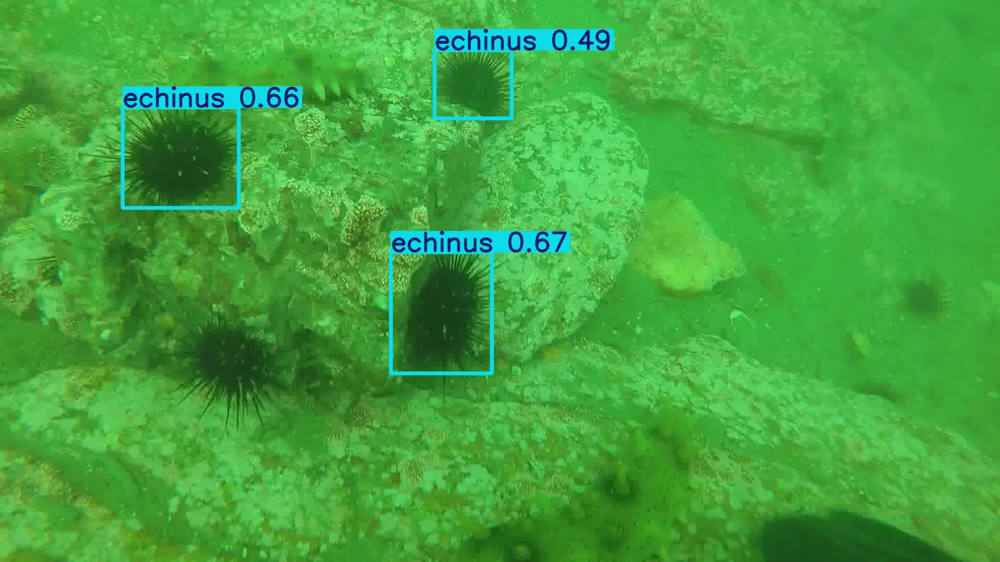

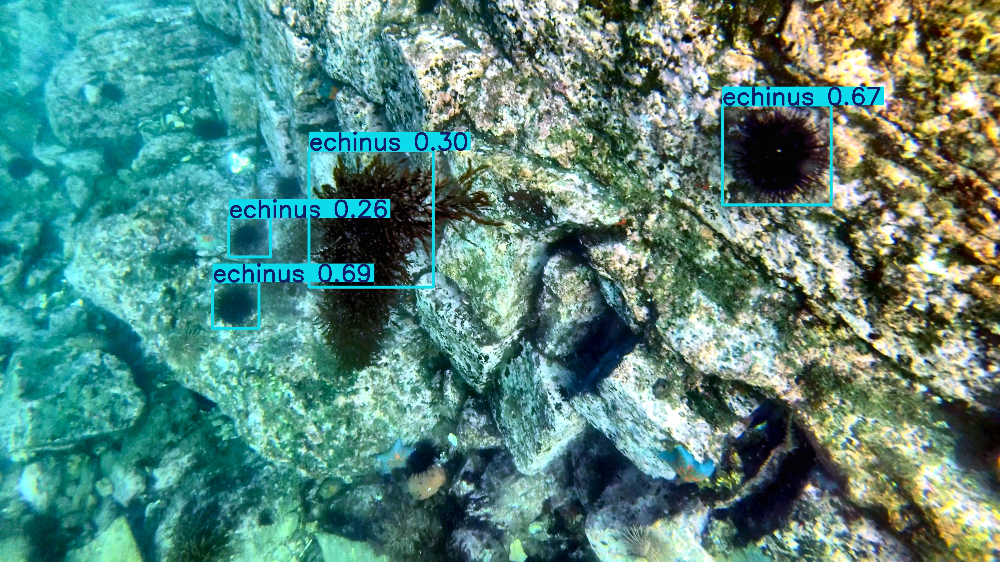

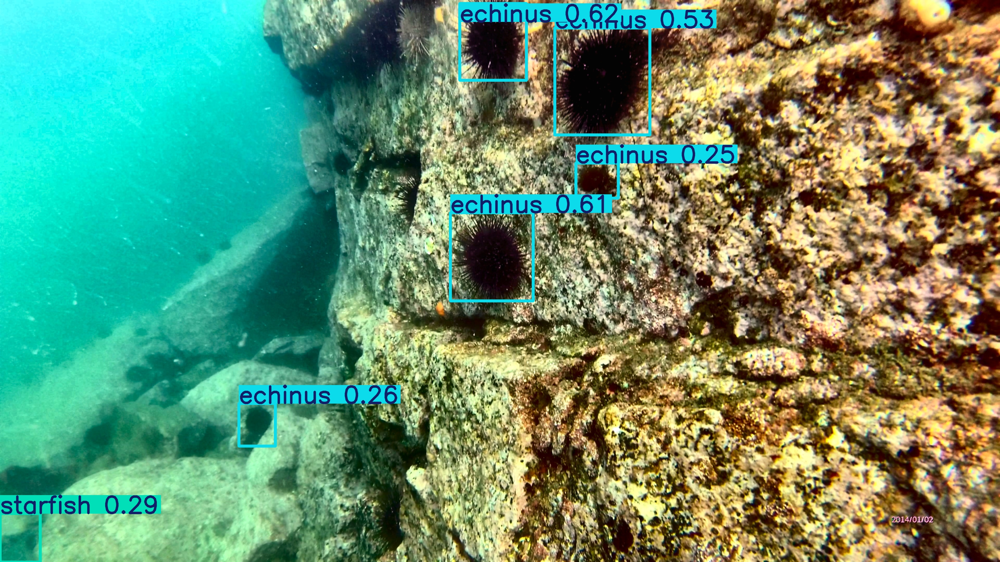

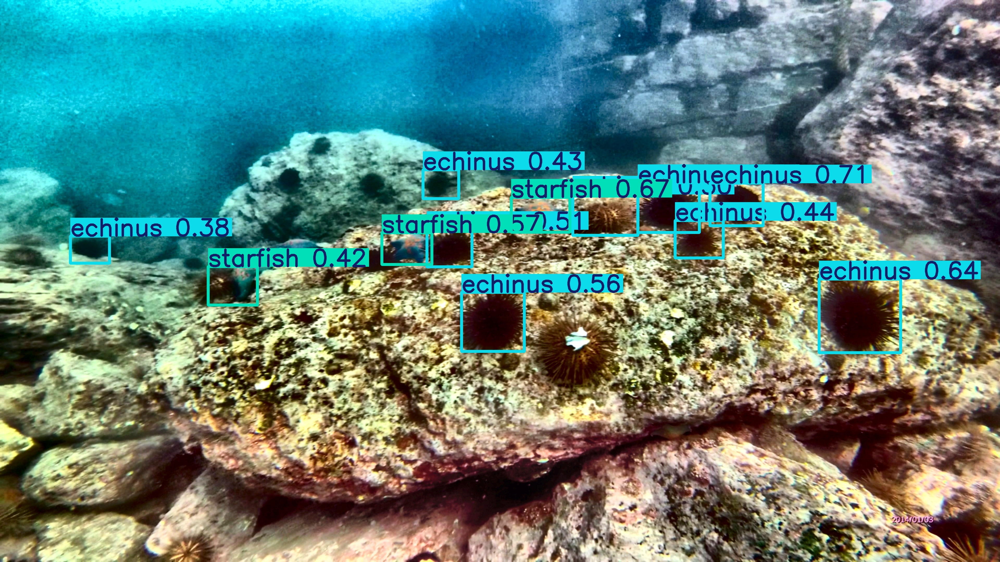

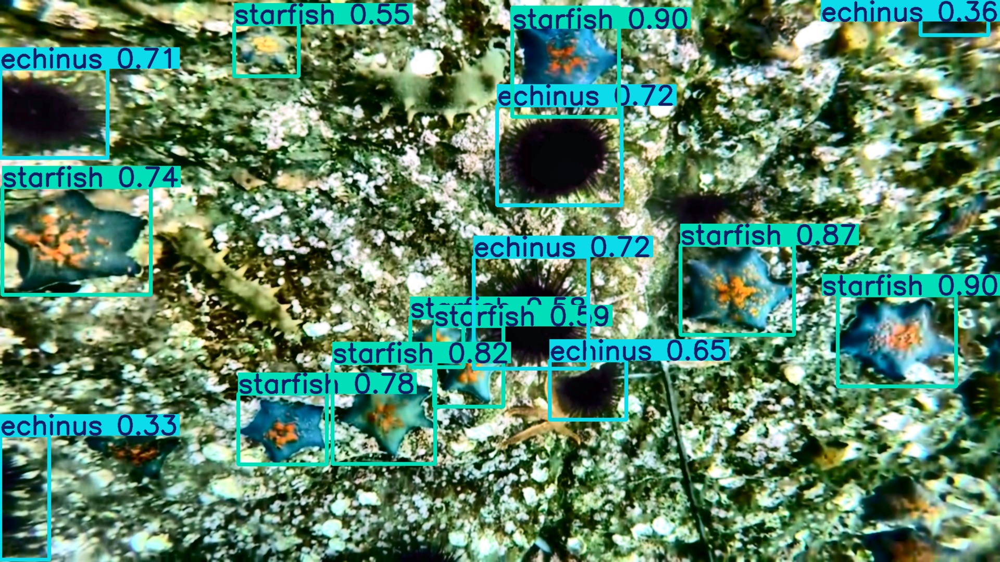

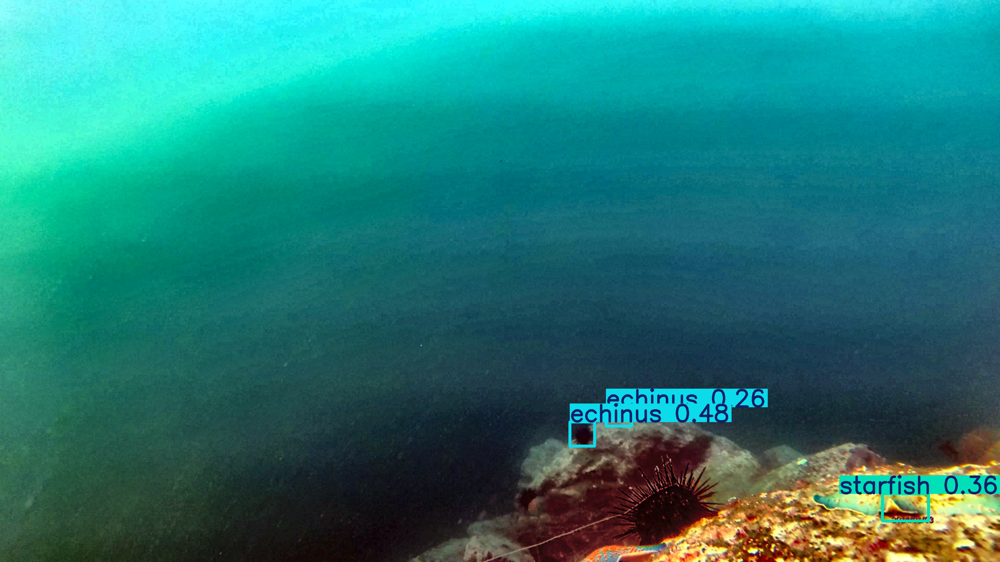

In [ ]:


import glob
from IPython.display import Image, display
from ultralytics import YOLO

model_path = '/content/drive/MyDrive/Underwater_Project/best1.pt'
model = YOLO(model_path)

test_images_dir = '/content/drive/MyDrive/Underwater_Project/Test_Images'

print(" Running predictions on real, unseen underwater images...")

results = model.predict(
    source=test_images_dir,
    conf=0.25,
    iou=0.45,
    save=True,
    project='/content/drive/MyDrive/Underwater_Project',
    name='Final_Predictions',
    exist_ok=True
)

print("\n Predictions complete and saved to your Drive! Here is a sneak peek:")

output_dir = '/content/drive/MyDrive/Underwater_Project/Final_Predictions'

result_images = glob.glob(f'{output_dir}/*.jpg')

for img_path in result_images[:10]:
    display(Image(filename=img_path, width=600))